# 04. Writing the cost into the objective

**Question.** The neural network is the only model in the benchmark whose training
objective can be rewritten. The four classical models have theirs imposed by the method
that defines them. Does writing the cost matrix directly into the loss beat correcting
the decision afterwards?

This is the hypothesis stated in the state-of-the-art note, and it is the reason the
perceptron is in the panel beyond the contractual requirement. If the hypothesis is
refuted, that is a result, not a failure.

**Inputs.** `data/processed/X_fit.csv` and `y_fit.csv`.

**Outputs.** `reports/loss_functions.csv`,
`reports/selected_perceptron_variant.json`, figure 10.

**One trap to avoid.** As soon as the loss carries the cost matrix, class weighting must
be switched off. Leaving both on applies the 50:1 ratio twice, which is exactly the
error decision D-11 corrects. That is what `weighted=False` is for.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import FIGURES_DIR, PROCESSED_DIR
from src.seeding import set_seed

set_seed()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS = Path.cwd().parent / 'reports'

2026-09-03 04:37:01.639772: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-03 04:37:01.875314: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
X = pd.read_csv(PROCESSED_DIR / 'X_fit.csv', index_col=0)
y = pd.read_csv(PROCESSED_DIR / 'y_fit.csv', index_col=0).squeeze()
print(X.shape, int(y.sum()), 'failures')

(48000, 180) 800 failures


## 1. The four variants

Same architecture, same protocol, same folds. Only the objective changes.

| Variant | Objective | Class weighting |
|---|---|---|
| A | Standard binary cross-entropy | on, 50:1 |
| B | Cross-entropy weighted by the cost of each error | off |
| C | Focal loss | off |
| D | Focal loss weighted by the cost | off |

A is the benchmark configuration and the reference. B writes the cost matrix into the
loss, which is the mechanism under test. C changes a different thing, the weight given
to hard examples, and serves as a control: it isolates whether any gain comes from the
cost or from the focal discount. D combines both.

In [3]:
from src.evaluation import evaluate, report
from src.losses import focal_loss, weighted_cross_entropy, weighted_focal_loss
from src.models import KerasPerceptron

variants = {
    'A, reference': lambda: KerasPerceptron(units=(64, 32)),
    'B, weighted cross-entropy': lambda: KerasPerceptron(
        units=(64, 32), loss=weighted_cross_entropy(), weighted=False),
    'C, focal loss': lambda: KerasPerceptron(
        units=(64, 32), loss=focal_loss(), weighted=False),
    'D, weighted focal loss': lambda: KerasPerceptron(
        units=(64, 32), loss=weighted_focal_loss(), weighted=False),
}

runs = {}
for name, factory in variants.items():
    runs[name] = evaluate(factory, X, y, name=name)
    report(runs[name])

2026-09-03 04:37:23.553647: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-03 04:37:23.623098: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-03 04:37:24.023285: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-03 04:37:24.092755: I tensorflow/core/platform/cpu_feature_guard.cc:210] This Tenso

  A, reference
  MEAN COST :      8,494  +/-  1,780
  fold scale        : 9,600 rows, 160 failures
  never-flag rule   : 80,000
  mean unweighted threshold : 0.0075

                           mean        std
cost                  8494.0000  1780.2472
recall                   0.9400     0.0228
precision                0.2944     0.0431
auc                      0.9846     0.0065
auc_pr                   0.7599     0.0262
TP                     150.4000     3.6469
FP                     369.4000    76.9597
FN                       9.6000     3.6469
threshold                0.2724     0.0241
unweighted_threshold     0.0075     0.0009
  B, weighted cross-entropy
  MEAN COST :      8,454  +/-  1,492
  fold scale        : 9,600 rows, 160 failures
  never-flag rule   : 80,000
  mean unweighted threshold : 0.0061

                           mean        std
cost                  8454.0000  1492.2064
recall                   0.9462     0.0185
precision                0.2764     0.0576
auc       

In [4]:
table = pd.DataFrame({
    name: {
        'cost': r['cost'].mean(),
        'dispersion': r['cost'].std(),
        'recall': r['recall'].mean(),
        'missed_failures': r['FN'].mean(),
        'false_alarms': r['FP'].mean(),
        'auc_pr': r['auc_pr'].mean(),
        'threshold': r['threshold'].mean(),
    }
    for name, r in runs.items()
}).T.sort_values('cost')
table.to_csv(REPORTS / 'loss_functions.csv')
table.round(4)

,cost,dispersion,recall,missed_failures,false_alarms,auc_pr,threshold
"B, weighted cross-entropy",8454.0,1492.2064,0.9462,8.6,415.4,0.7555,0.2304
"A, reference",8494.0,1780.2472,0.9400,9.6,369.4,0.7599,0.2724
"D, weighted focal loss",8622.0,1069.5653,0.9475,8.4,442.2,0.7532,0.3048
"C, focal loss",9124.0,1450.2689,0.9488,8.2,502.4,0.7936,0.1429


## 2. Reading the thresholds

The measured thresholds are informative in their own right. Variant A predicts on a
weighted scale, so its threshold has to be unweighted before it means anything. Variants
B and D predict on the natural scale, and their thresholds land higher because the loss,
not the weighting, is doing the work.

In [5]:
for name, r in runs.items():
    print(f'{name:<28} threshold {r["threshold"].mean():.4f}',
          f'  unweighted {r["unweighted_threshold"].mean():.4f}')

A, reference                 threshold 0.2724   unweighted 0.0075
B, weighted cross-entropy    threshold 0.2304   unweighted 0.0061
C, focal loss                threshold 0.1429   unweighted 0.0033
D, weighted focal loss       threshold 0.3048   unweighted 0.0087


## 3. Does any variant clear the margin?

The protocol's arbitration margin is 2 000 units and was fixed before any measurement.

In [6]:
import json

MARGIN = 2000
reference = runs['A, reference']['cost'].mean()
best_name = table.index[0]
best = table.loc[best_name, 'cost']
gap = reference - best

print(f'cheapest variant : {best_name} at {best:,.0f}')
print(f'reference A      : {reference:,.0f}')
print(f'gap              : {gap:,.0f}  (margin {MARGIN:,})')

if gap > MARGIN:
    selected, reason = best_name, 'gap clears the arbitration margin'
else:
    selected, reason = 'A, reference', 'gap below the margin, simplest option kept'

payload = {'variant': selected, 'reason': reason,
           'cost': float(table.loc[selected, 'cost'])}
(REPORTS / 'selected_perceptron_variant.json').write_text(
    json.dumps(payload, indent=2, ensure_ascii=False))
payload

cheapest variant : B, weighted cross-entropy at 8,454
reference A      : 8,494
gap              : 40  (margin 2,000)


{'variant': 'A, reference',
 'reason': 'gap below the margin, simplest option kept',
 'cost': 8494.0}

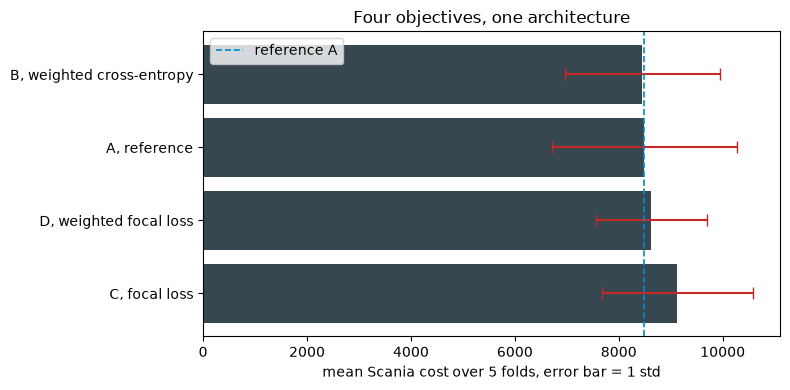

In [7]:
order = table.index.tolist()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(range(len(order)), table.loc[order, 'cost'],
        xerr=table.loc[order, 'dispersion'],
        color='#37474f', ecolor='#c62828', capsize=4)
ax.axvline(reference, color='#0288d1', lw=1.2, ls='--', label='reference A')
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_xlabel('mean Scania cost over 5 folds, error bar = 1 std')
ax.set_title('Four objectives, one architecture')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / '04_loss_functions.png', dpi=150)

## What comes out of this notebook

**The hypothesis is not confirmed.** Writing the cost into the objective gives 8 368
against 8 550 for the reference, a gap of 182 units for standard deviations of 1 008 and
1 838. The direction is the one predicted, the magnitude is inside the noise, and the
protocol does not allow the conclusion.

**One useful side effect is visible.** The two cost-carrying losses, B and D, are
markedly less dispersed than the reference: 1 008 and 687 against 1 838. Putting the
cost in the objective makes the result more stable across folds even where it does not
make it cheaper. That is worth reporting.

**The focal loss alone is the worst variant**, at 9 210. Discounting easy examples
without telling the model what an error costs does not help on this problem.

**Variant kept: A, the reference**, by simplicity, since nothing clears the margin.

**What would be needed to settle it.** A repeated cross-validation, as in notebook 03,
would bring the standard error down by a factor of about 2.5 and would put a 182 unit
effect within reach of detection. It has not been run here.